## Pandas Visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import  seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yousrakerrouch/irrigation-prediction-clean/irrigation_prediction_clean.csv")
df

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Silt,7.01,26.67,0.86,0.76,27.61,52.20,1075.12,7.41,19.66,Sugarcane,Sowing,Kharif,Drip,Groundwater,2.62,Yes,92.44,South,Low
9996,Clay,5.40,49.44,0.90,1.19,34.03,52.31,1591.84,9.86,5.66,Maize,Sowing,Kharif,Rainfed,Groundwater,4.87,No,15.46,South,Low
9997,Loamy,4.97,60.63,0.99,1.30,36.68,68.16,2384.87,10.75,13.40,Potato,Harvest,Kharif,Canal,Groundwater,10.08,Yes,116.36,North,Low
9998,Loamy,7.12,44.33,1.56,1.08,31.50,64.83,2397.01,4.03,3.05,Sugarcane,Harvest,Kharif,Rainfed,Reservoir,11.11,Yes,118.17,East,Low


In [3]:
target = "Irrigation_Need"

num_cols = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon",
    "Electrical_Conductivity", "Temperature_C", "Humidity",
    "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh",
    "Field_Area_hectare", "Previous_Irrigation_mm"
]

cat_cols = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage",
    "Season", "Irrigation_Type", "Water_Source",
    "Mulching_Used", "Region"
]

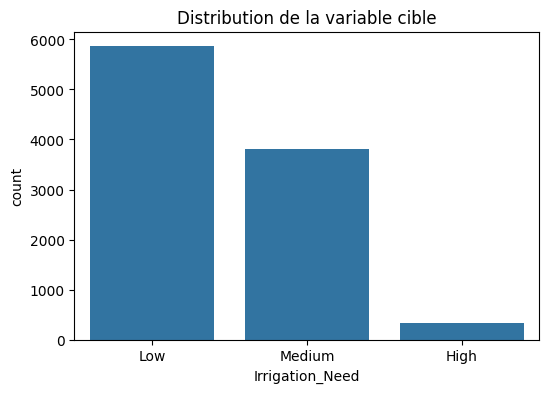

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Irrigation_Need"
)

plt.title("Distribution de la variable cible")
plt.show()

### Interpretation

Cette visualisation montre la distribution des classes de la variable cible. Elle permet d'identifier un éventuel déséquilibre entre les catégories Low, Medium et High.

## Distribution des variables numériques

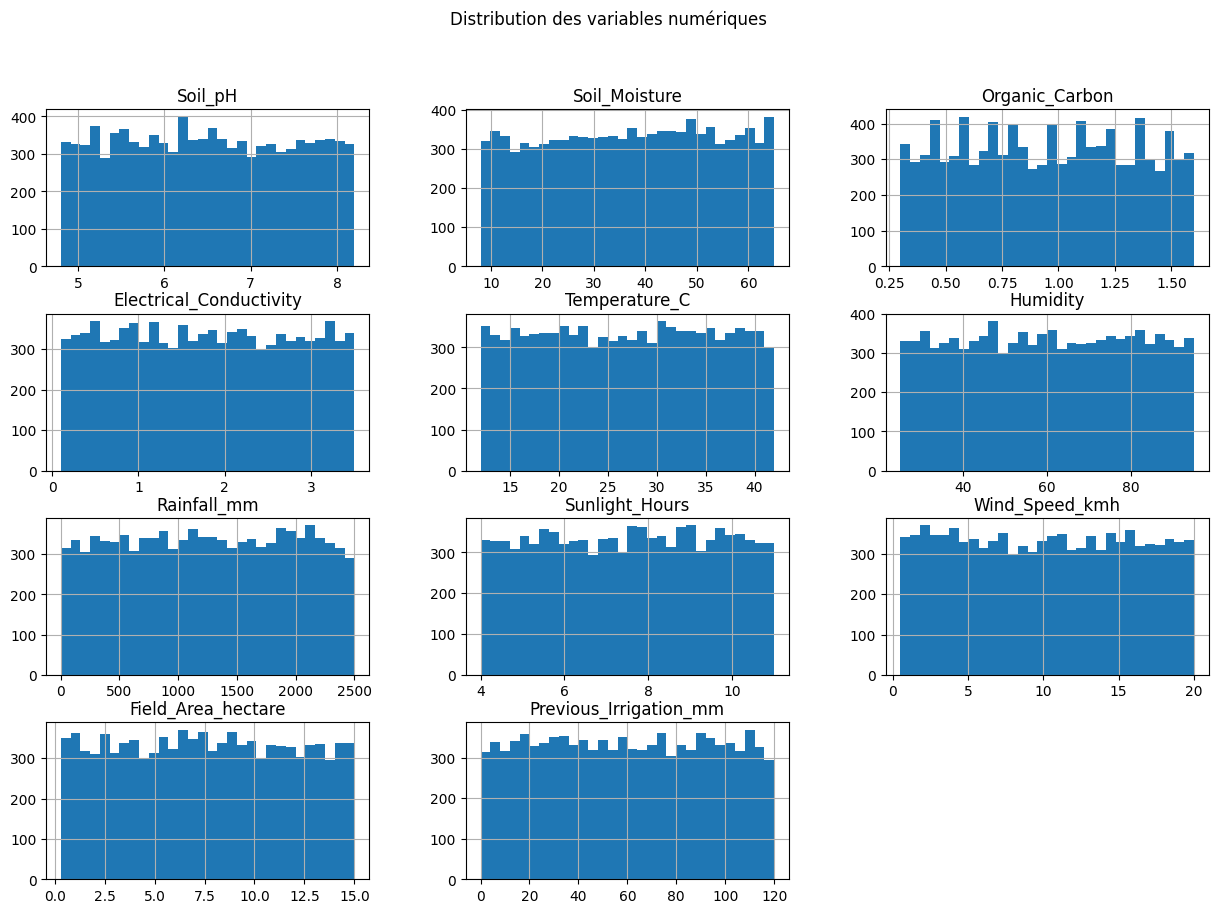

In [5]:
df[num_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("Distribution des variables numériques")
plt.show()

### Interpretation

Les histogrammes permettent d'observer la répartition des valeurs, les plages de variation ainsi que la présence éventuelle d'asymétries dans les données.

## Détection des valeurs aberrantes

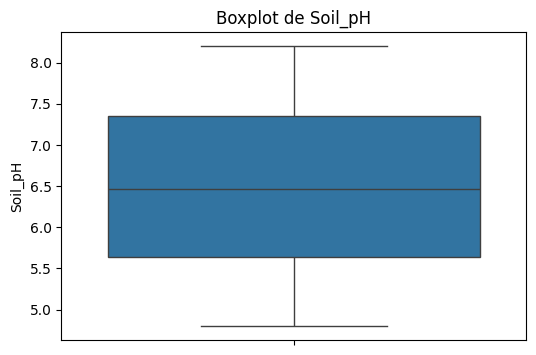

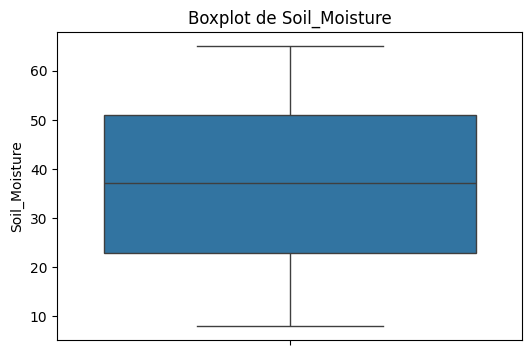

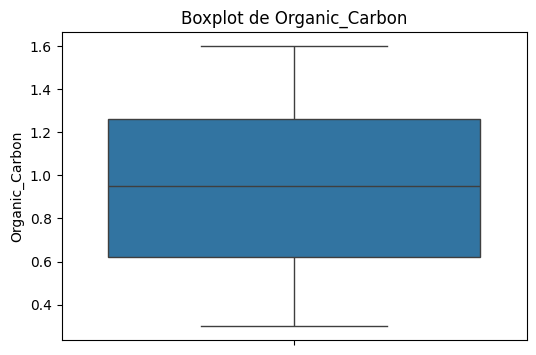

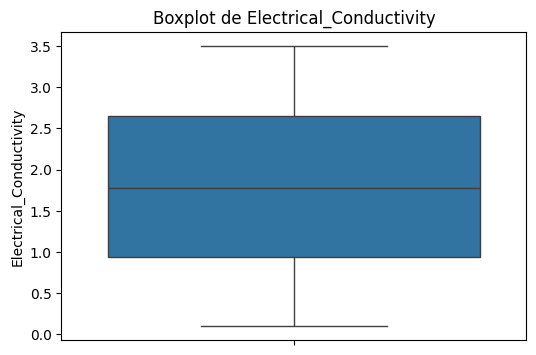

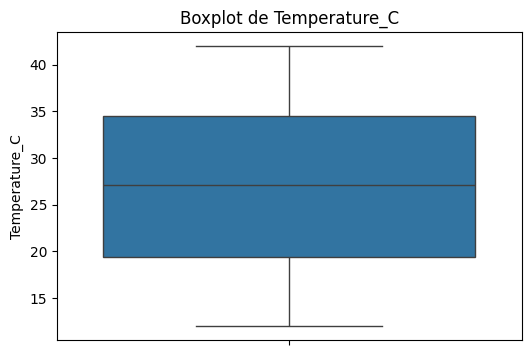

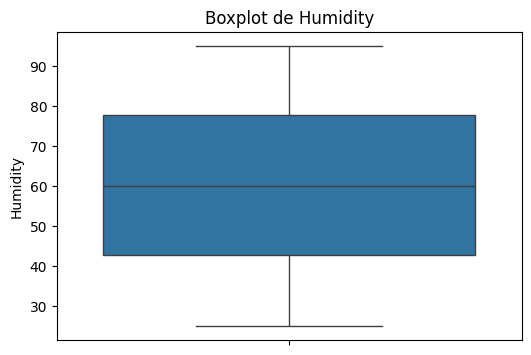

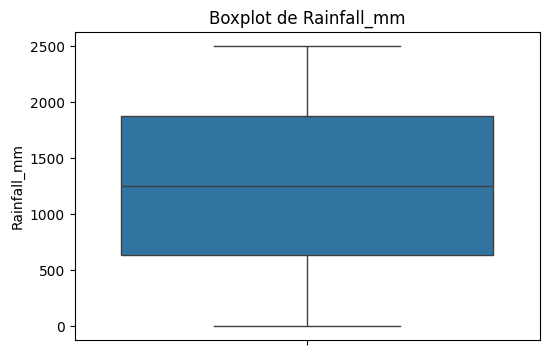

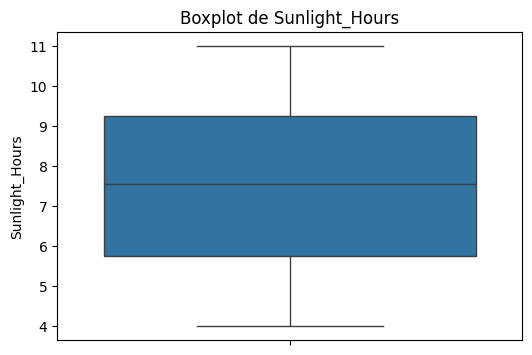

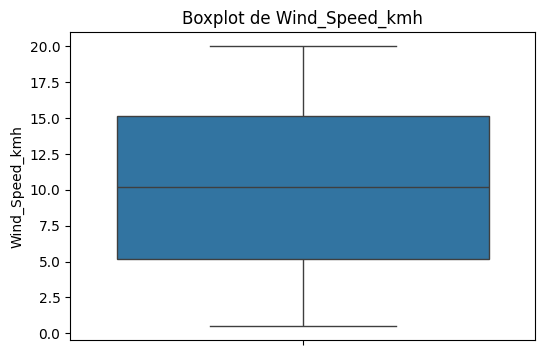

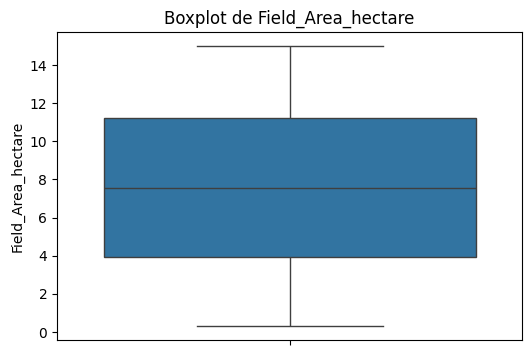

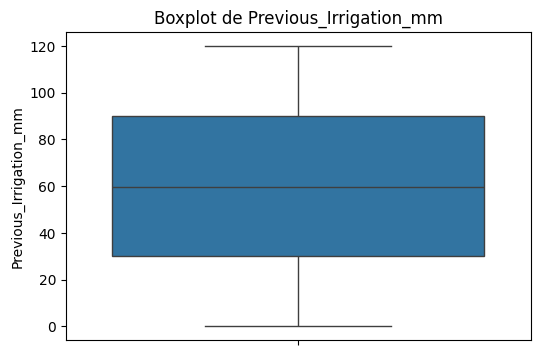

In [6]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        y=df[col]
    )

    plt.title(f"Boxplot de {col}")

    plt.show()

## Relation entre les variables numériques et la cible

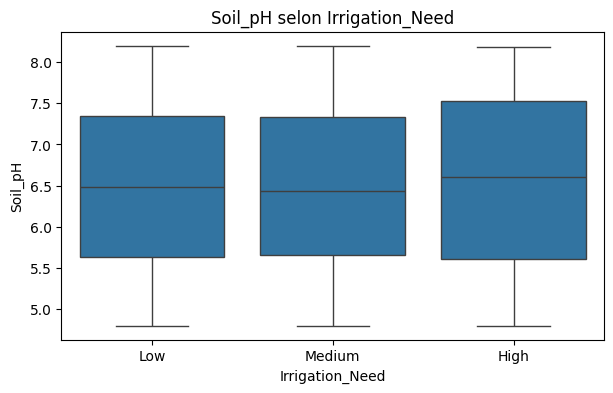

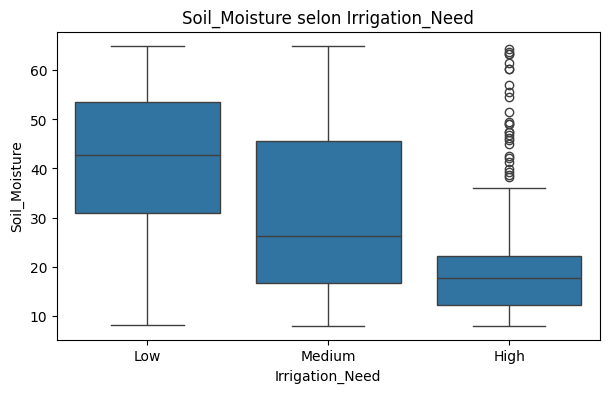

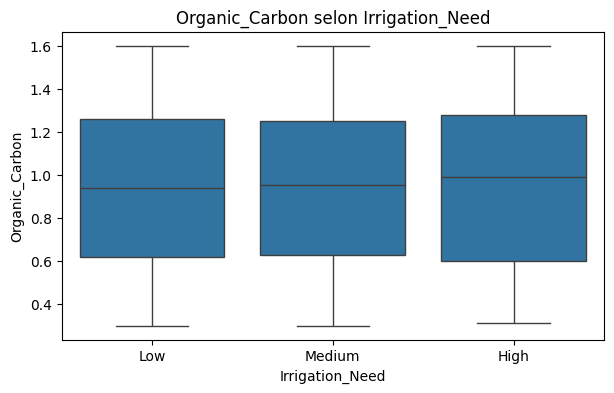

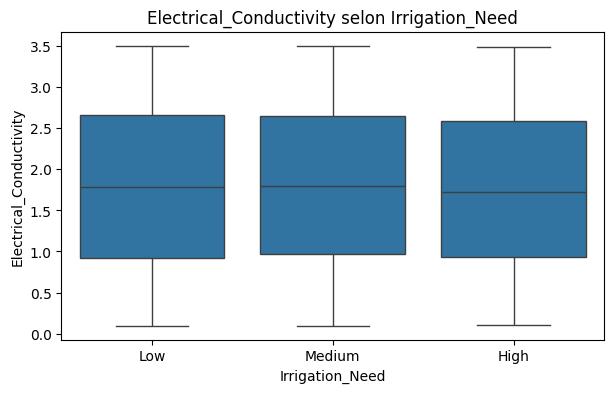

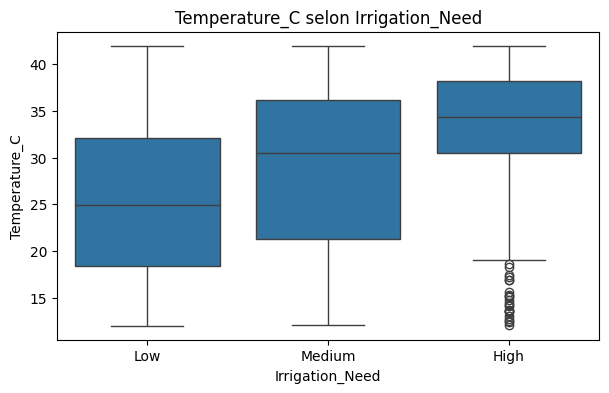

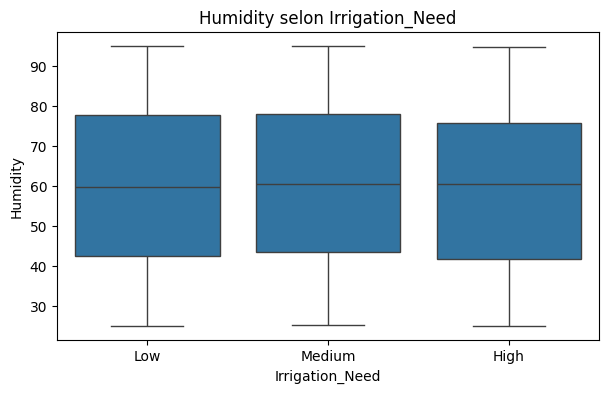

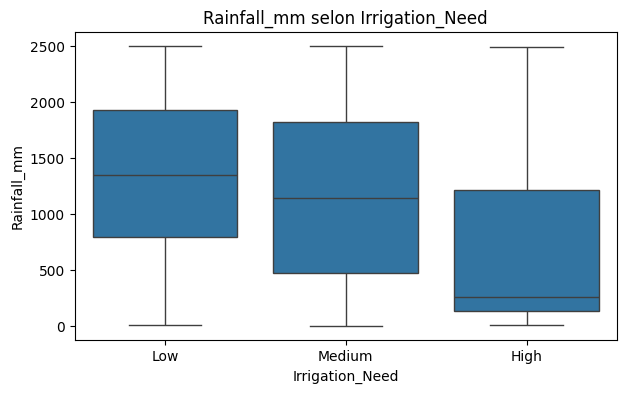

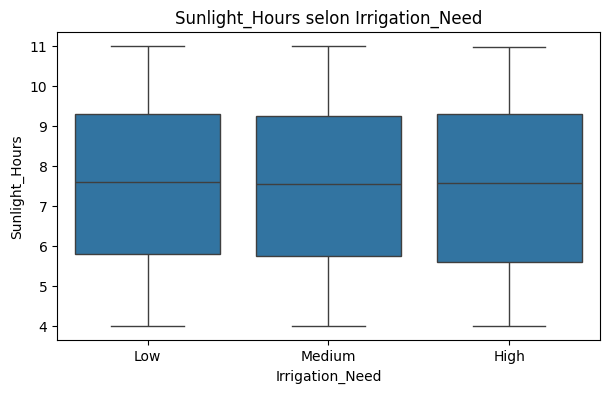

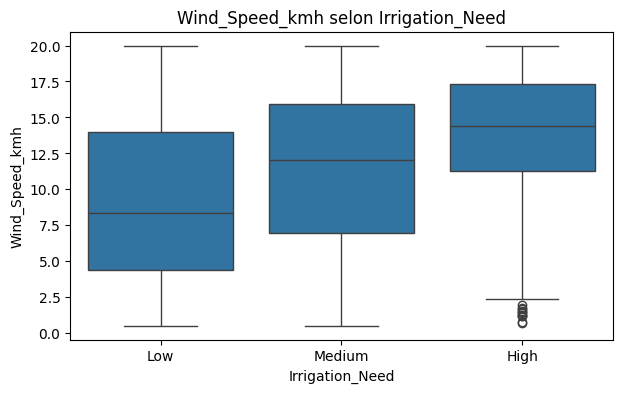

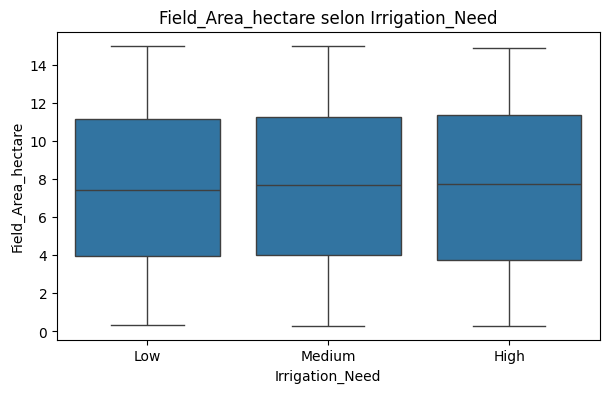

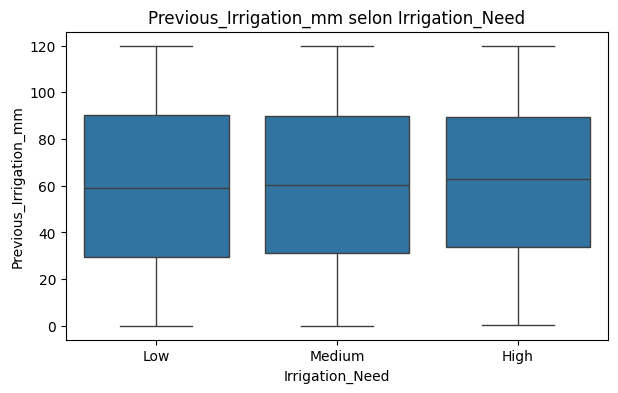

In [7]:
for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Irrigation_Need",
        y=col
    )

    plt.title(f"{col} selon Irrigation_Need")

    plt.show()

### Interpretation

Les différences observées entre les classes Low, Medium et High permettent d'identifier les variables les plus susceptibles d'influencer les besoins en irrigation.

## Distribution des variables catégorielles

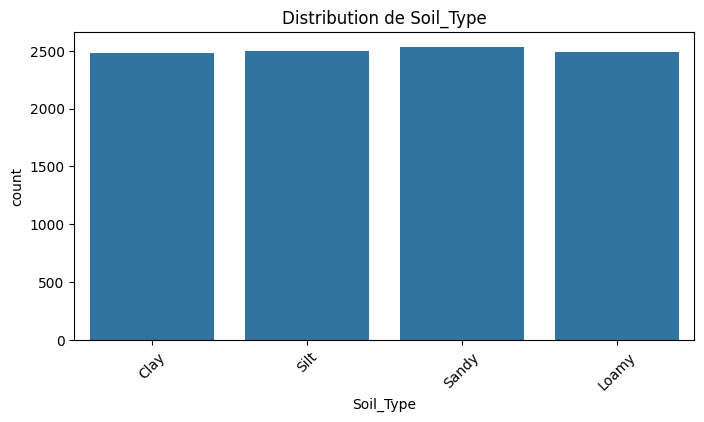

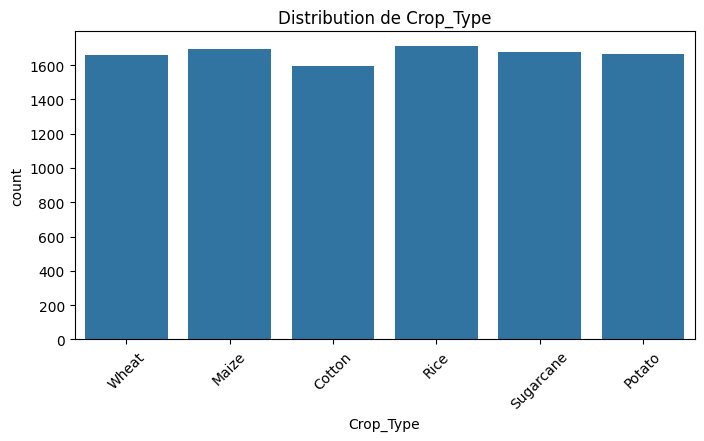

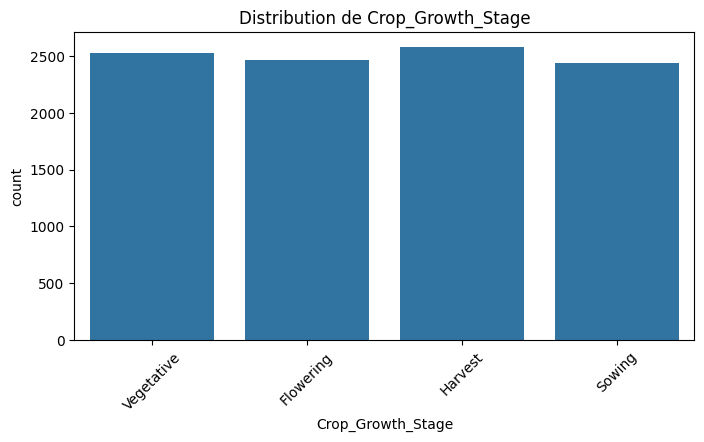

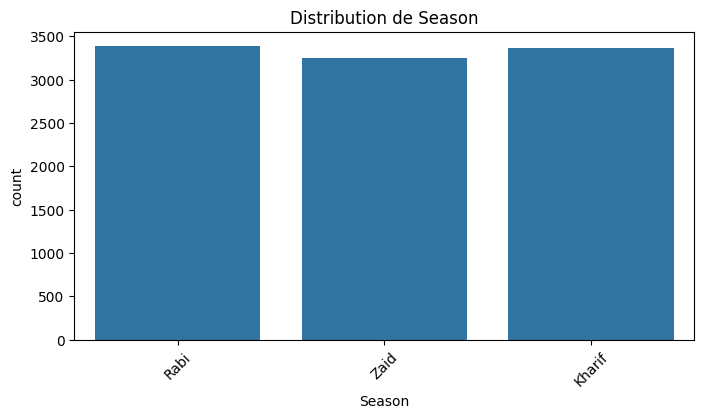

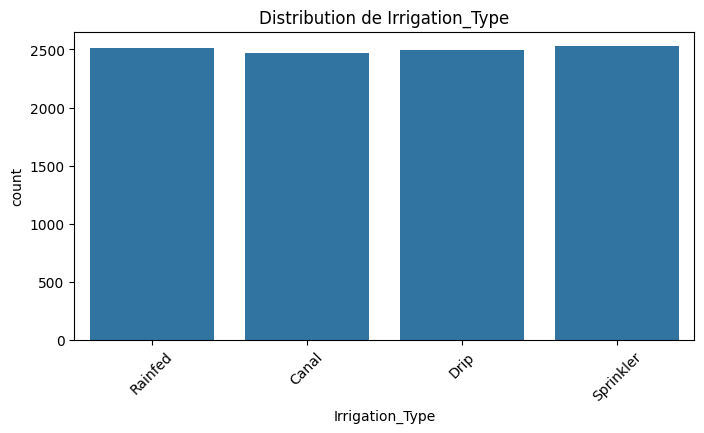

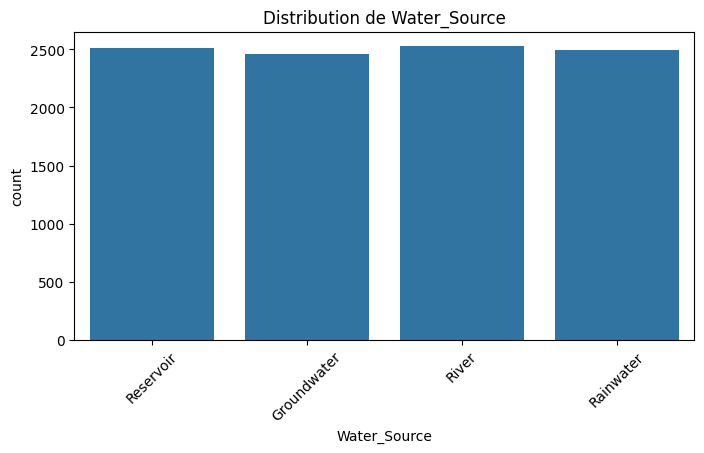

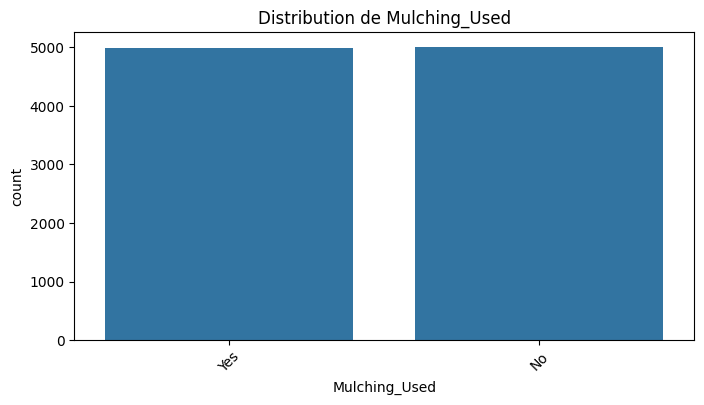

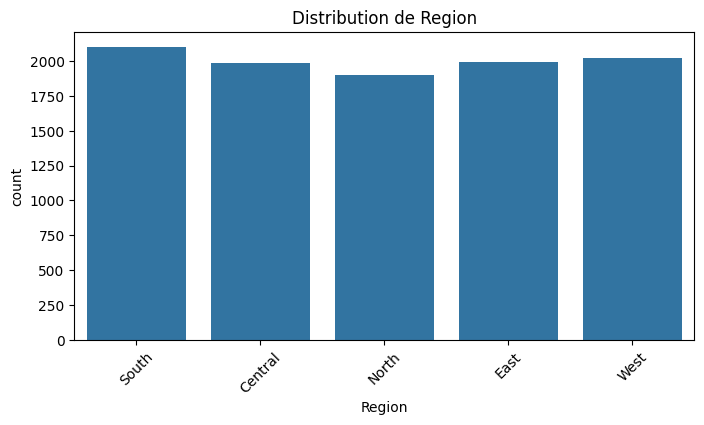

In [8]:
for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f"Distribution de {col}")

    plt.xticks(rotation=45)

    plt.show()

### Interpretation

Cette analyse permet d'identifier les catégories les plus fréquentes dans le dataset ainsi que leur répartition.

## Relation entre les variables catégorielles et la cible

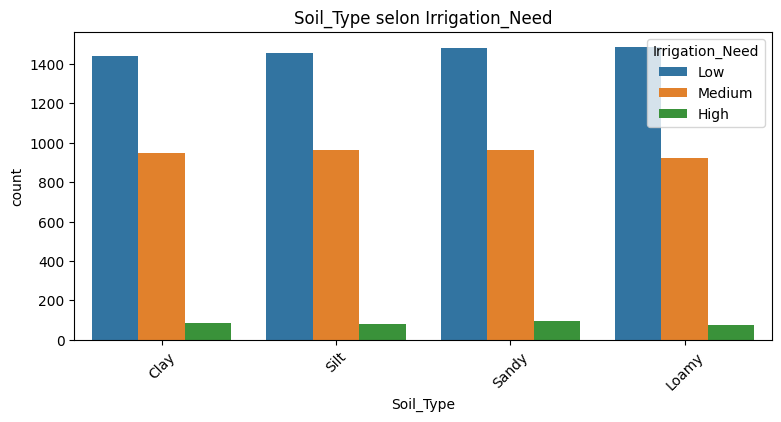

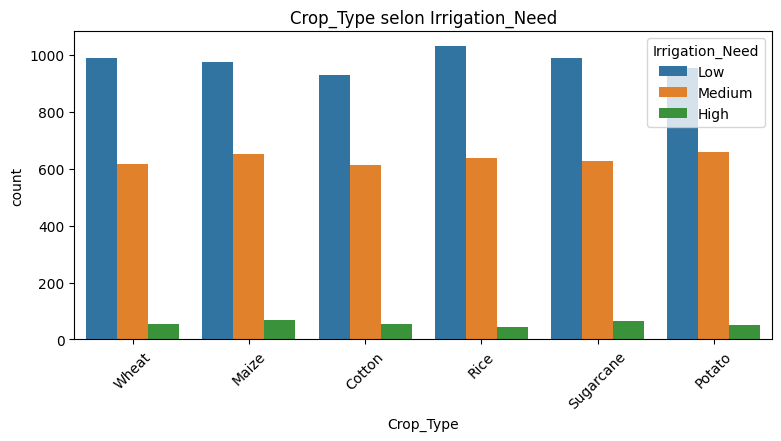

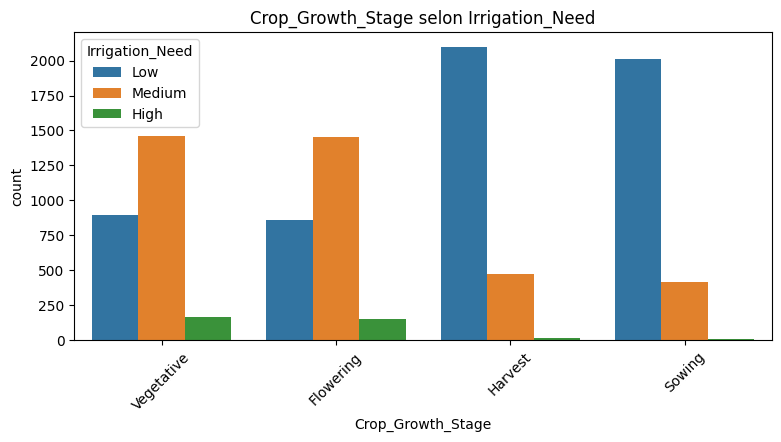

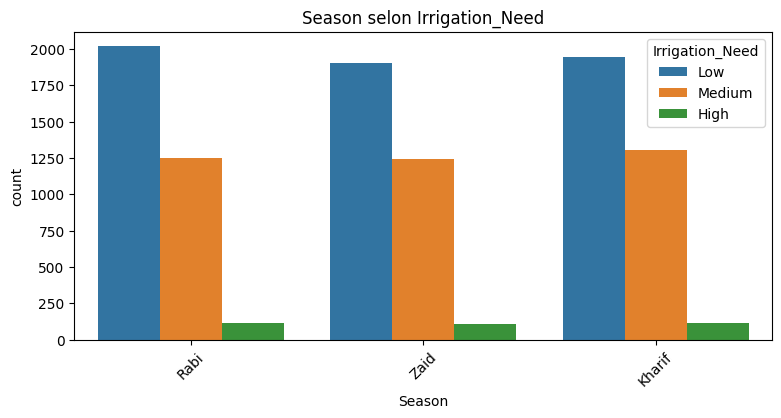

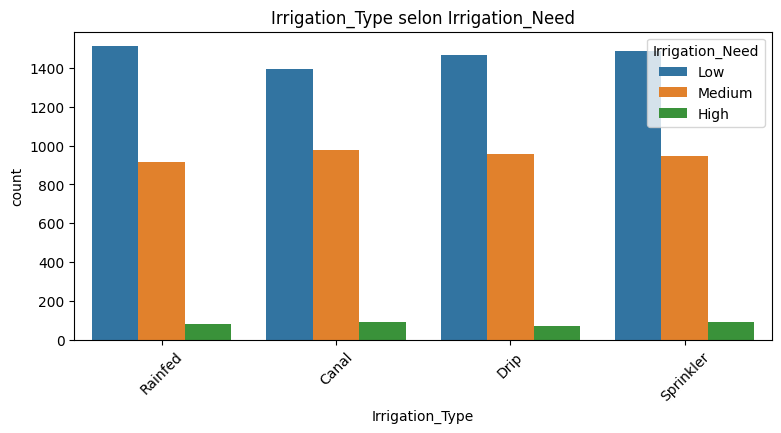

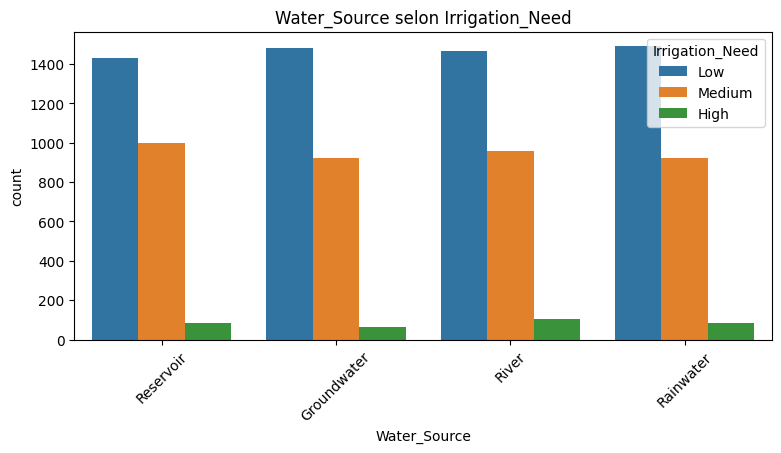

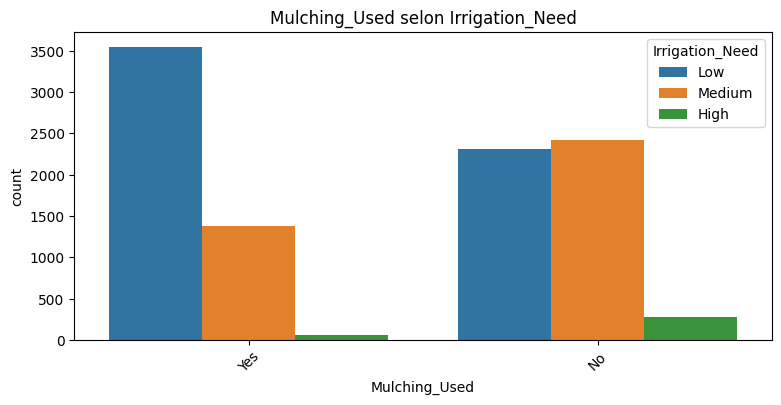

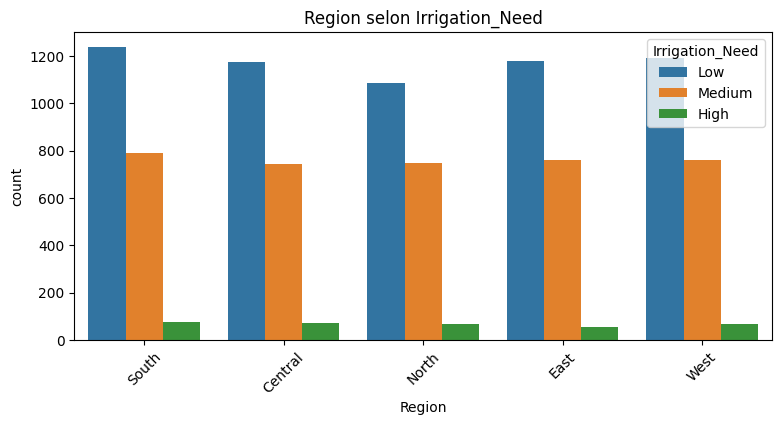

In [9]:
for col in cat_cols:

    plt.figure(figsize=(9,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Irrigation_Need"
    )

    plt.title(f"{col} selon Irrigation_Need")

    plt.xticks(rotation=45)

    plt.show()

### Interpretation

Certaines catégories semblent être davantage associées à des besoins d'irrigation élevés ou faibles.

## Matrice de corrélation

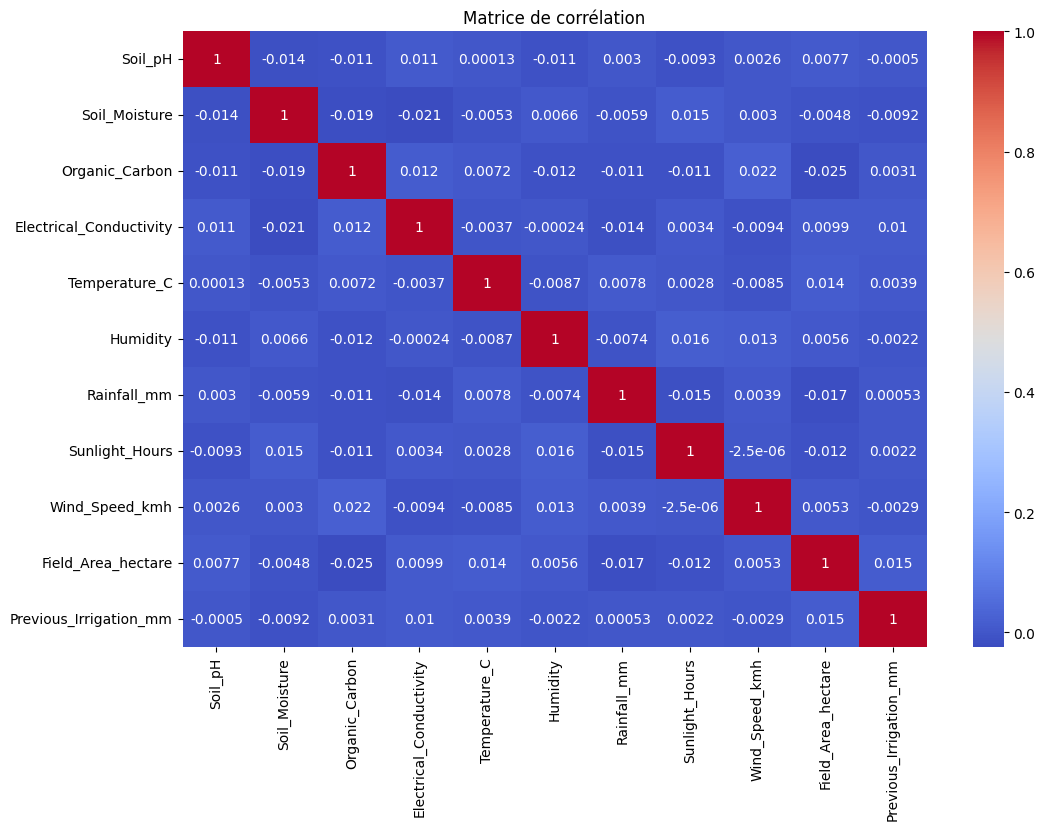

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    
)

plt.title("Matrice de corrélation")

plt.show()

### Interpretation

Les coefficients de corrélation observés sont globalement faibles, ce qui suggère une faible dépendance linéaire entre les variables numériques.

# Conclusion

L'analyse exploratoire a permis de mieux comprendre la structure du jeu de données et les facteurs susceptibles d'influencer les besoins en irrigation. Les résultats obtenus serviront de base pour les prochaines étapes du projet, notamment le prétraitement des données et le développement des modèles de Machine Learning.